In [1]:
import os
import importlib
import sys
import torch
import matplotlib.pyplot as plt
import pandas as pd
import amplfi

device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
os.environ['AMPLFI_OUTDIR'] = '/home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/sg'
os.environ['AMPLFI_DATADIR'] = '/home/aframe/dev/o4_llpic/amplfi/hl/data'

In [2]:
model = "sg"
ckpt_path = f"/home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/finished_model/{model}/best.ckpt"
config_path = f"/home/jack.redepenning/amplfi_dir/amplfi/runs/{model}/sg.yaml"
param_path = "/home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/finished_model/sg/parameters.hdf5"

/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS
/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/lightning/pytorch/cli.py:528: LightningCLI's args parameter is intended to run from within Python like if it were from the command line. To prevent mistakes it is not recommended to provide both args and command line argument

2025-08-25 08:43:21,023 - root - INFO - Downloading data to /home/aframe/dev/o4_llpic/amplfi/hl/data


Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: redep028 (redep028-university-of-minnesota). Use `wandb login --relogin` to force relogin


2025-08-25 08:43:34,440 - FlowDataset - INFO - Setting up data for stage TrainerFn.TESTING
2025-08-25 08:43:34,447 - FlowDataset - INFO - Using 83 files with a total duration of 9.444 days for testing
2025-08-25 08:43:34,517 - FlowDataset - INFO - Inferred sample rate of 2048.0 Hz
2025-08-25 08:43:34,598 - FlowDataset - INFO - Loaded 1 waveforms for testing
2025-08-25 08:43:34,620 - FlowDataset - INFO - Building torch Modules and transferring to device
2025-08-25 08:43:34,686 - FlowDataset - INFO - Using pre-fit standard scaler


Restoring states from the checkpoint path at /home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/finished_model/sg/best.ckpt
/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:362: The dirpath has changed from '/projects/bcse/jredepenning//amplfi-outdir/runs/sg/train_logs/amplfi/id1zxrpn/checkpoints' to '/home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/sg/train_logs/amplfi/lqwpig50/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
Loaded model weights from the checkpoint at /home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/finished_model/sg/best.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

2025-08-25 08:44:17,074 - FlowModel - INFO - Removed 67/10000 total samples outside of prior range
2025-08-25 08:44:27,469 - FlowModel - INFO - Making PP plot


08:44 bilby INFO    : Key: KS-test p-value
08:44 bilby INFO    : frequency: 0.8519077821403402
08:44 bilby INFO    : quality: 0.46773381657102586
08:44 bilby INFO    : hrss: 0.11778918755662948
08:44 bilby INFO    : phase: 0.75485754555522
08:44 bilby INFO    : eccentricity: 0.6978757676432095
08:44 bilby INFO    : dec: 0.9773482331621866
08:44 bilby INFO    : psi: 0.6886137118695259
08:44 bilby INFO    : phi: 0.05396154233363526
08:44 bilby INFO    : Combined p-value: 0.5964187809104375


Crossmatching skymaps:   0%|          | 0/1 [00:00<?, ?it/s]

/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/ligo/skymap/postprocess/crossmatch.py:395: RuntimeWarning: invalid value encountered in subtract
  contour_dists = (hi - lo).tolist()
/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/ligo/skymap/postprocess/crossmatch.py:414: RuntimeWarning: invalid value encountered in divide
  dP_dV = dP / dV
TEST Profiler Report

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|  Action                                                                                                                                                           	|  Mean duration (s)	|  Num calls      	|  Total time (s) 	|  Percentage %   	|
-------------------------------------------------------------------

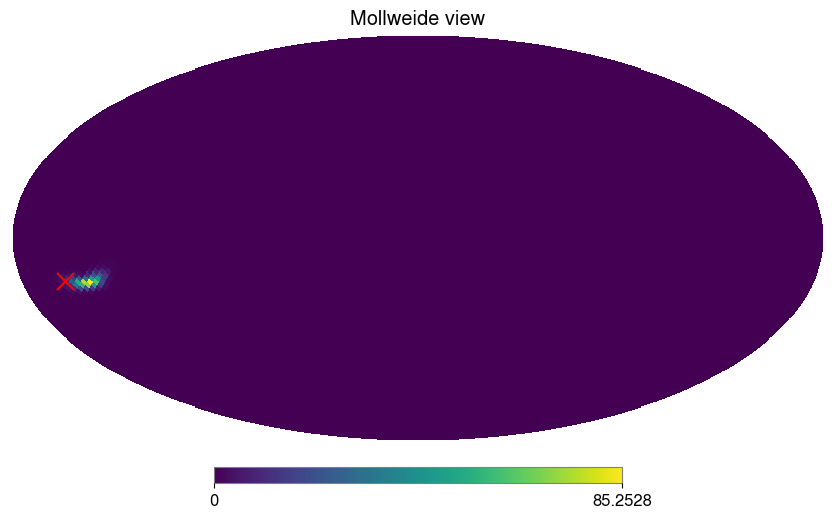

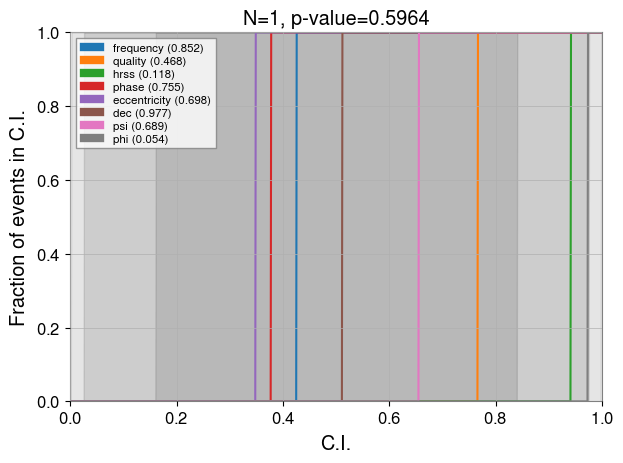

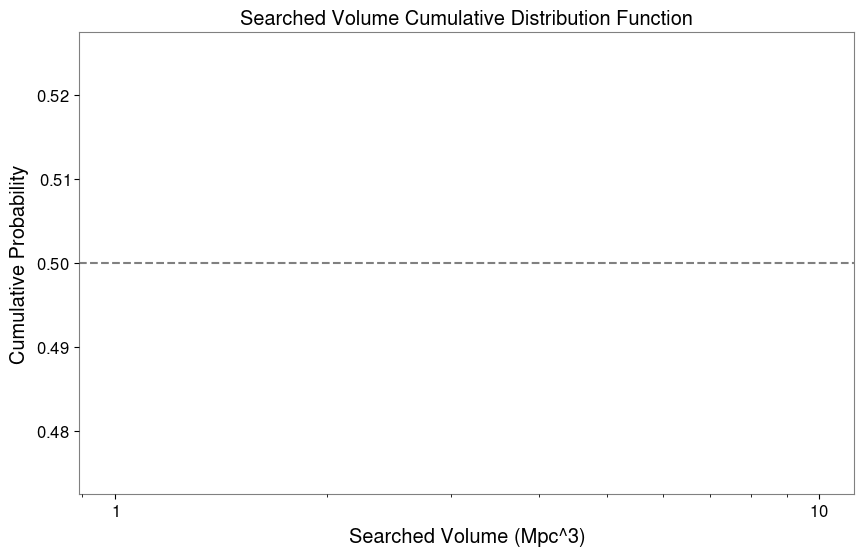

In [3]:
from amplfi.train.data.datasets.base import AmplfiDataset
from amplfi.train.models.base import AmplfiModel
from amplfi.train.cli.flow import AmplfiFlowCLI

cli = AmplfiFlowCLI(
        AmplfiModel,
        AmplfiDataset,
        subclass_mode_model=True,
        subclass_mode_data=True,
        save_config_kwargs={"overwrite": True},
        seed_everything_default=101588,
        args=[
        "test",             # Subcommand
        "--config", config_path,
        "--ckpt_path", ckpt_path,
        ]
)

### Set parameters to prepare for generating sine Gaussian waveforms

In [4]:
# Desired duration of time-domain waveform
waveform_duration = 7
# Sample rate of all the data we'll be using today
sample_rate = 2048

nyquist = sample_rate / 2
num_samples = int(waveform_duration * sample_rate)
num_freqs = num_samples // 2 + 1

### Define priors for waveform

In [5]:
from ml4gw.distributions import LogUniform
from torch.distributions import Uniform
from ml4gw.waveforms import SineGaussian
import numpy as np

# On CPU, keep the number of waveforms around 100. On GPU, you can go higher
num_waveforms = 1

param_dict = {
    "frequency": Uniform(32, 1024, False),
    "quality": Uniform(25, 75, False),
    "hrss": Uniform(1e-21, 2e-21, False),
    "phase": Uniform(0, 2 * np.pi, False),
    "eccentricity": Uniform(0, 0.01, False),
}

# And then sample from each of those distributions
params = {
    k: v.sample((num_waveforms,)).cpu() for k, v in param_dict.items()
}

In [6]:

approximant = SineGaussian(sample_rate, waveform_duration)

cross, plus = approximant(**params)
times = torch.arange(0, waveform_duration, 1 / sample_rate)
# Calling the approximant with the frequency array, reference frequency, and waveform parameters
# returns the cross and plus polarizations
print(cross.shape, plus.shape)

torch.Size([1, 14336]) torch.Size([1, 14336])


In [7]:
# Set up data coming from both detectors
from ml4gw.gw import get_ifo_geometry, compute_observed_strain

# The interferometer geometry for V1 and K1 are also in ml4gw
ifos = ["H1", "L1"]
tensors, vertices = get_ifo_geometry(*ifos)

In [8]:
datamodule = cli.datamodule
model = cli.model
model.eval();

### Load in background data 

In [9]:
waveforms_dataloader, background_dataloader = datamodule.test_dataloader().datasets
background_data = next(iter(background_dataloader))
background_data = background_data[0][0].repeat(num_waveforms, 1, 1)
print(background_data.shape)

torch.Size([1, 2, 38912])


In [10]:
kernel_length = cli.datamodule.hparams.kernel_length
fduration = cli.datamodule.hparams.fduration
length = kernel_length + fduration
sample_rate = cli.datamodule.hparams.sample_rate
fftlength = cli.datamodule.hparams.fftlength
size = int(length * sample_rate)
print(size)

14336


In [11]:
X = background_data
splits = [X.size(-1) - size, size]
background, X = torch.split(X, splits, dim=-1)

In [12]:
print(background.shape)
print(X.shape)

torch.Size([1, 2, 24576])
torch.Size([1, 2, 14336])


In [13]:
kernel_length = cli.datamodule.hparams.kernel_length
fduration = cli.datamodule.hparams.fduration
length = kernel_length + fduration
sample_rate = cli.datamodule.hparams.sample_rate
fftlength = cli.datamodule.hparams.fftlength
size = int(length * sample_rate)
print(size)

14336


### Inject sg waveforms into the background data and use amplfi to predict waveform parameters

In [14]:
strain, asds, parameters, snrs = datamodule.inject(background_data, cross, plus, params)
batch = strain, asds, parameters
print(strain.shape)
print(asds.shape)
print(parameters.shape)
print(snrs.shape)
result = model.predict_step(batch, _)

torch.Size([1, 2, 10240])
torch.Size([1, 2, 4995])
torch.Size([1, 8])
torch.Size([1])
2025-08-25 08:46:52,775 - FlowModel - INFO - Removed 23/10000 total samples outside of prior range


### Corner Plot

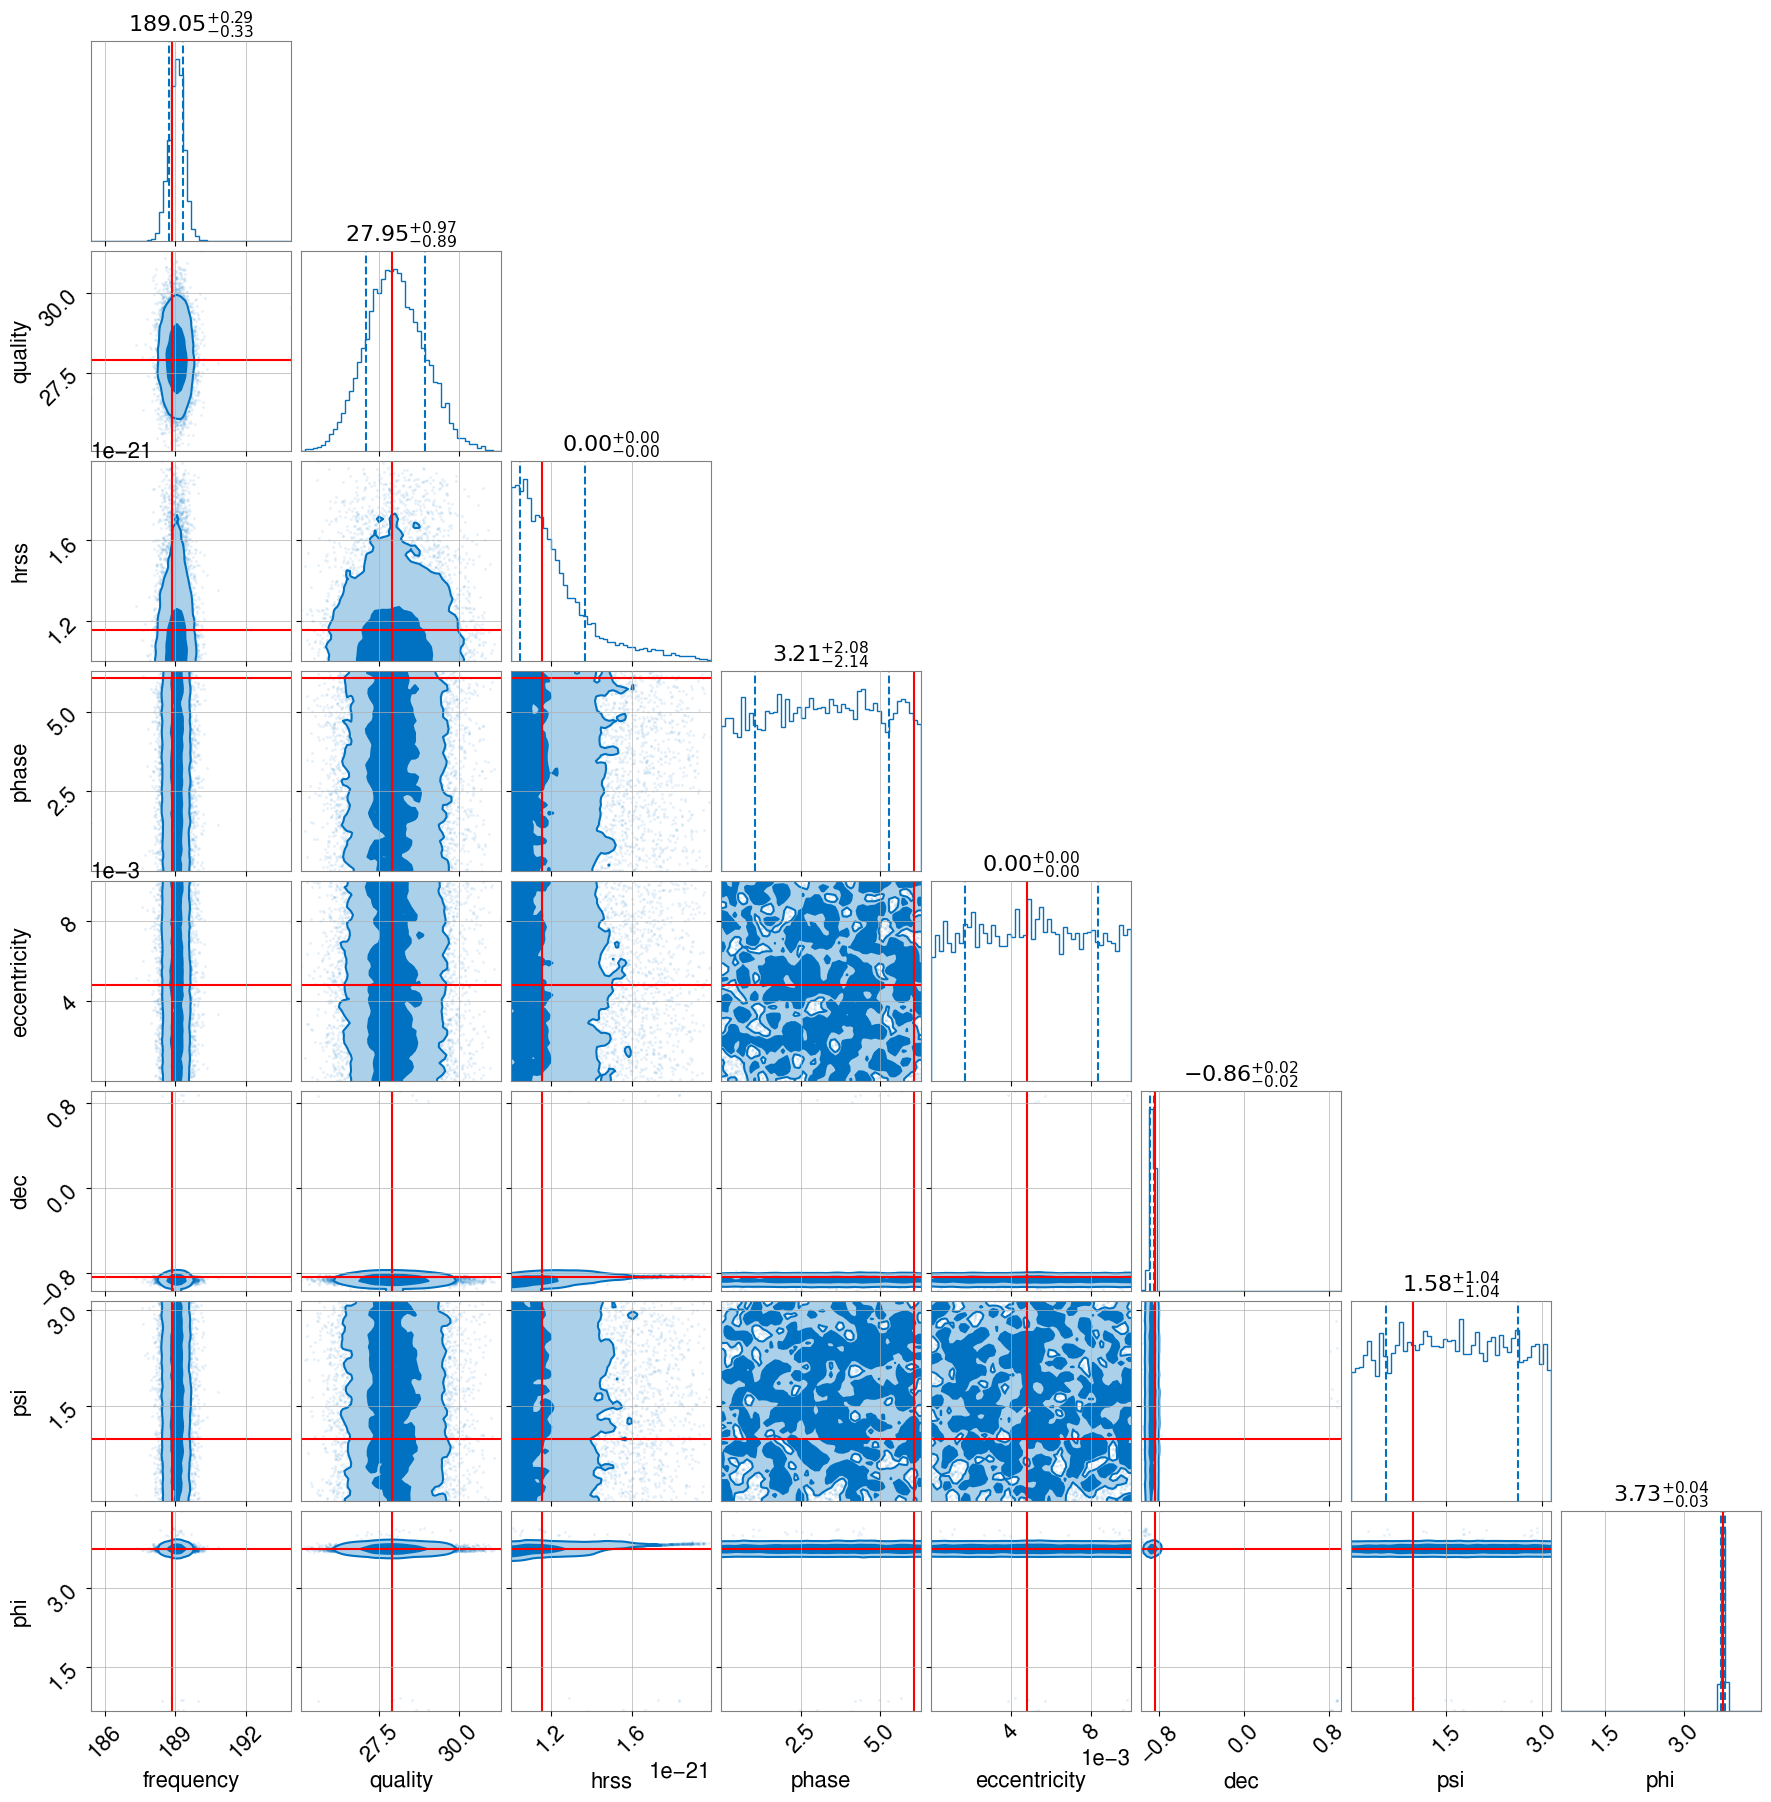

In [18]:
import corner
param_vals = np.array([v.item() for k, v in params.items()])
fig = result.plot_corner(save=False, levels=(0.5, 0.9));
corner.overplot_lines(fig, param_vals, color='r')

### Take the average of the 10000 samples generated from amplfi to generate a single waveform and see how this compares to waveform generated using actual values

In [19]:
posterior = result.posterior
post = {key: torch.tensor([posterior[key].mean()]) for key in posterior.keys()
        if key in param_dict.keys()}

# Phase of the two waveforms do not match up unless I set the phase for the posterior to be the
# same as the prior
# post['phase'] = params['phase']

### Generate waveforms from prior values

In [24]:
waveforms = compute_observed_strain(
    dec=torch.tensor([params['dec']]),
    psi=torch.tensor([params['psi']]),
    phi=torch.tensor([params['phi']]),
    detector_tensors=tensors,
    detector_vertices=vertices,
    sample_rate=sample_rate,
    cross=cross,
    plus=plus,
)

### Generate waveforms from average of posterior values

In [25]:
cross_pred, plus_pred = approximant(**post)

waveforms_pred = compute_observed_strain(
    dec=torch.tensor([posterior['dec'].mean()]),
    psi=torch.tensor([posterior['psi'].mean()]),
    phi=torch.tensor([posterior['phi'].mean()]),
    detector_tensors=tensors,
    detector_vertices=vertices,
    sample_rate=sample_rate,
    cross=cross_pred,
    plus=plus_pred,
)
print(waveforms_pred.shape)

TypeError: SineGaussian.forward() missing 4 required positional arguments: 'quality', 'frequency', 'hrss', and 'eccentricity'

In [ ]:
mean_waveform_pred = waveforms_pred.mean(0)
print(mean_waveform_pred.shape)
print(waveforms.shape)

torch.Size([2, 14336])
torch.Size([1, 2, 14336])


### Plot waveforms together

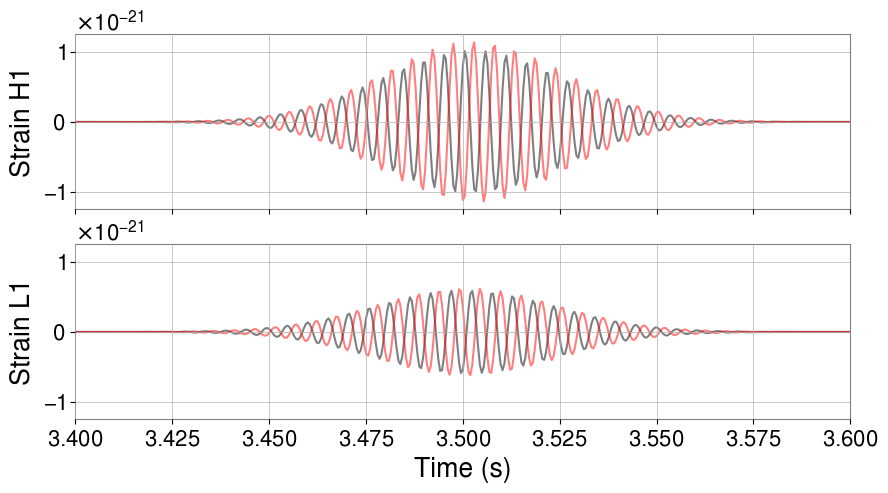

In [ ]:
fig, ax = plt.subplots(2, sharex=True, sharey=True, figsize=(10, 5))
ax[0].plot(times, waveforms[0, 0].cpu(), color='k', alpha=0.5)
ax[0].plot(times, mean_waveform_pred[0].cpu (), color='r', alpha=0.5)
ax[1].plot(times, waveforms[0, 1].cpu(), color='k', alpha=0.5)
ax[1].plot(times, mean_waveform_pred[1].cpu(), color='r', alpha=0.5)
ax[1].set_xlabel("Time (s)")
ax[0].set_ylabel("Strain H1")
ax[1].set_ylabel("Strain L1")
ax[1].set_xlim(3.4, 3.6)
plt.show()

### Try generating all 10000 waveforms first, then taking the average of all of the waveforms

In [ ]:
posterior = result.posterior
post = {key: torch.tensor([posterior[key]]) for key in posterior.keys()
        if key in param_dict.keys()}

In [ ]:
cross_pred, plus_pred = approximant(**post)

waveforms_pred = compute_observed_strain(
    dec=torch.tensor([posterior['dec']]),
    psi=torch.tensor([posterior['psi']]),
    phi=torch.tensor([posterior['phi']]),
    detector_tensors=tensors,
    detector_vertices=vertices,
    sample_rate=sample_rate,
    cross=cross_pred,
    plus=plus_pred,
)
print(waveforms_pred.shape)

torch.Size([9967, 2, 14336])


In [ ]:
percentile_waveform_pred = np.percentile(waveforms_pred.cpu(), [5, 95], axis=0)
print(percentile_waveform_pred.shape)
print(mean_waveform_pred.shape)
print(waveforms.shape)

(2, 2, 14336)
torch.Size([2, 14336])
torch.Size([1, 2, 14336])


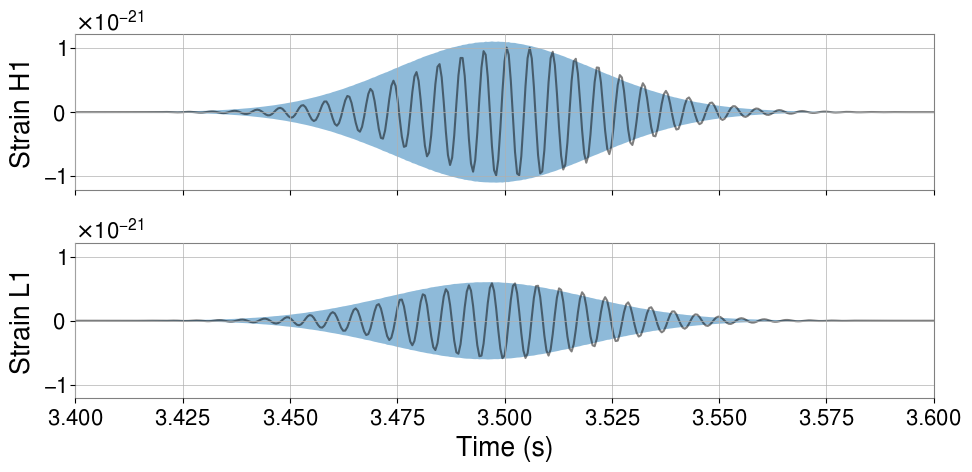

In [ ]:
# time_shift = times - 0.033
fig, ax = plt.subplots(2, sharex=True, sharey=True, figsize=(10, 5))
ax[0].plot(times, waveforms[0, 0].cpu(), color='k', alpha=0.5)
ax[0].fill_between(times, percentile_waveform_pred[0, 0], percentile_waveform_pred[1, 0], alpha=0.5)
ax[1].plot(times, waveforms[0, 1].cpu(), color='k', alpha=0.5)
ax[1].fill_between(times, percentile_waveform_pred[0, 1], percentile_waveform_pred[1, 1], alpha=0.5)
ax[1].set_xlabel("Time (s)")
ax[0].set_ylabel("Strain H1")
ax[1].set_ylabel("Strain L1")
ax[1].set_xlim(3.4, 3.6)
plt.tight_layout()
# plt.savefig("./images/sg_percentile.png")
plt.show()